In [14]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
# Setup Path
base_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
metadata_path = os.path.join(base_path, "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

# Load CSV
df = pd.read_csv(metadata_path)

print(f"Total samples: {len(df)}")
print("\nLima baris pertama:")
display(df.head())

Total samples: 10015

Lima baris pertama:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


/tmp/ipykernel_56/2412410890.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="dx", data=df, palette="viridis")


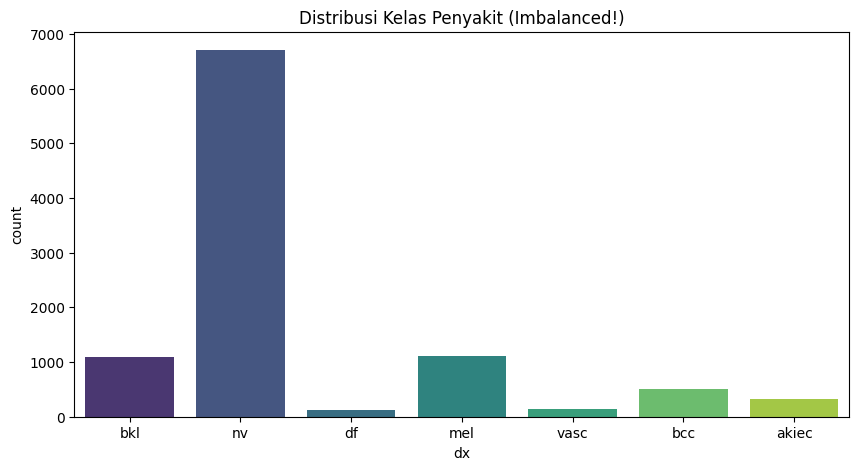

In [3]:
# Mencari semua path gambar di folder part_1 dan part_2
image_dir1 = os.path.join(base_path, "HAM10000_images_part_1")
image_dir2 = os.path.join(base_path, "HAM10000_images_part_2")

# Buat kamus lokasi gambar
image_paths = {os.path.splitext(f)[0]: os.path.join(image_dir1, f) 
               for f in os.listdir(image_dir1) if f.endswith('.jpg')}
image_paths.update({os.path.splitext(f)[0]: os.path.join(image_dir2, f) 
                    for f in os.listdir(image_dir2) if f.endswith('.jpg')})

# Tambahkan kolom path
df["path"] = df["image_id"].map(image_paths)

# Visualisasi Distribusi Penyakit
plt.figure(figsize=(10,5))
sns.countplot(x="dx", data=df, palette="viridis")
plt.title("Distribusi Kelas Penyakit (Imbalanced!)")
plt.show()

In [4]:
# 1. Pastikan Label Encoding dilakukan LEBIH DULU
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Membuat kolom 'label' dari kolom 'dx'
df["label"] = le.fit_transform(df["dx"]) 

num_classes = len(le.classes_)
class_names = le.classes_

# 2. Baru lakukan Splitting (Sekarang df["label"] sudah ada)
from sklearn.model_selection import train_test_split

# Split 1: 70% Train, 30% Sisanya (Temp)
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

# Split 2: Bagi Temp (30%) menjadi Val (15%) dan Test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print(f"✅ Data Latih (Train): {len(train_df)}")
print(f"✅ Data Validasi (Val): {len(val_df)}")
print(f"✅ Data Uji (Test): {len(test_df)}")

# --- VALIDASI 3 SPLIT ---
def check_3_split(t, v, ts):
    dist = pd.DataFrame({
        'Train (%)': t['dx'].value_counts(normalize=True)*100,
        'Val (%)': v['dx'].value_counts(normalize=True)*100,
        'Test (%)': ts['dx'].value_counts(normalize=True)*100
    })
    print("\n📊 Distribusi 3 Split (Harusnya mirip):")
    display(dist)

check_3_split(train_df, val_df, test_df)

✅ Data Latih (Train): 7010
✅ Data Validasi (Val): 1502
✅ Data Uji (Test): 1503

📊 Distribusi 3 Split (Harusnya mirip):


,Train (%),Val (%),Test (%)
dx,,,
nv,66.947218,66.977364,66.932801
mel,11.112696,11.118509,11.111111
bkl,10.970043,10.985353,10.978044
bcc,5.135521,5.126498,5.123087
akiec,3.266762,3.262317,3.260146
vasc,1.412268,1.398136,1.463739
df,1.155492,1.131824,1.131071


In [7]:
# Pastikan IMG_SIZE dan BATCH_SIZE sudah didefinisikan sebelumnya (misal: 224 dan 32)
IMG_SIZE = 224
BATCH_SIZE = 32

# 1. ImageDataGenerator dengan Augmentasi (Hanya untuk Train)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. ImageDataGenerator Tanpa Augmentasi (Hanya Rescale untuk Val dan Test)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# --- MEMBUAT GENERATOR ---

# Train Generator
train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col="path", y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="sparse", batch_size=BATCH_SIZE
)

# Validation Generator (INI YANG TADI HILANG)
val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col="path", y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="sparse", batch_size=BATCH_SIZE,
    shuffle=False
)

# Test Generator
test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col="path", y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="sparse", batch_size=BATCH_SIZE,
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


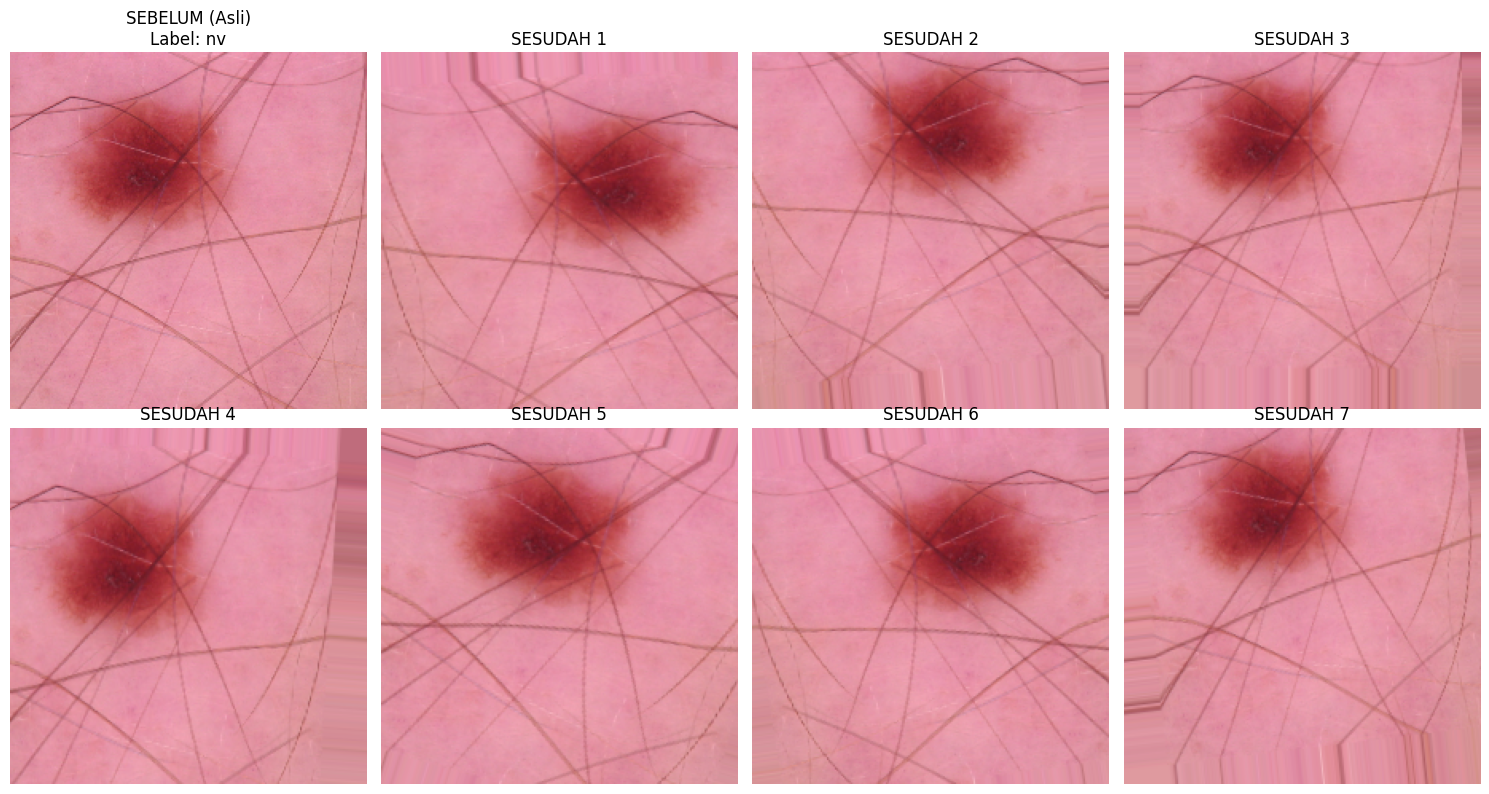

In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. Ambil satu contoh path gambar dari dataframe
sample_path = train_df['path'].iloc[0]
sample_label = train_df['dx'].iloc[0]

# 2. Load gambar asli (Sebelum Augmentasi)
img = load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = img_to_array(img)
samples = np.expand_dims(img_array, 0) # Format: (1, 224, 224, 3)

# 3. Siapkan iterator untuk augmentasi
# Kita gunakan train_datagen yang nilainya sudah di-rescale (0-1)
it = train_datagen.flow(samples, batch_size=1)

# 4. Visualisasi
plt.figure(figsize=(15, 8))

# Tampilkan Gambar Asli (Sebelum)
plt.subplot(2, 4, 1)
plt.imshow(img_array.astype('uint8')) # Tampilkan format asli
plt.title(f"SEBELUM (Asli)\nLabel: {sample_label}")
plt.axis('off')

# Tampilkan 7 Versi Augmentasi (Sesudah)
for i in range(7):
    plt.subplot(2, 4, i + 2)
    batch = next(it) # <--- PERBAIKAN DI SINI
    image = batch[0] 
    plt.imshow(image) # Langsung imshow karena sudah di-rescale ke 0-1
    plt.title(f"SESUDAH {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,219,562 (16.10 MB)

 Trainable params: 167,431 (654.03 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

...

 15/220 ━━━━━━━━━━━━━━━━━━━━ 2:19 683ms/step - accuracy: 0.1601 - loss: 2.3137

2026-03-28 02:12:57.757804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-28 02:12:57.892247: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-28 02:12:58.203588: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-28 02:12:58.344940: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-28 02:12:59.060208: E external/local_xla/xla/stream_

220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.1694 - loss: 2.1502

2026-03-28 02:16:12.824340: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-28 02:16:12.968092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-28 02:16:13.315806: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-28 02:16:13.457424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-28 02:16:14.168001: E external/local_xla/xla/stream_

220/220 ━━━━━━━━━━━━━━━━━━━━ 244s 987ms/step - accuracy: 0.1694 - loss: 2.1501 - val_accuracy: 0.0326 - val_loss: 1.9300 - learning_rate: 1.0000e-04
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 115s 523ms/step - accuracy: 0.1632 - loss: 2.0288 - val_accuracy: 0.0140 - val_loss: 1.9901 - learning_rate: 1.0000e-04
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 115s 521ms/step - accuracy: 0.1573 - loss: 1.9513 - val_accuracy: 0.0326 - val_loss: 1.9921 - learning_rate: 1.0000e-04
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.1742 - loss: 2.0044
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
220/220 ━━━━━━━━━━━━━━━━━━━━ 114s 520ms/step - accuracy: 0.1741 - loss: 2.0045 - val_accuracy: 0.0326 - val_loss: 1.9691 - learning_rate: 1.0000e-04
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 115s 520ms/step - accuracy: 0.1176 - loss: 2.0270 - val_accuracy: 0.0326 - val_loss: 1.9803 - learning_rate: 2.0000e-05
Restoring model weights from the end of the best epoch: 1.


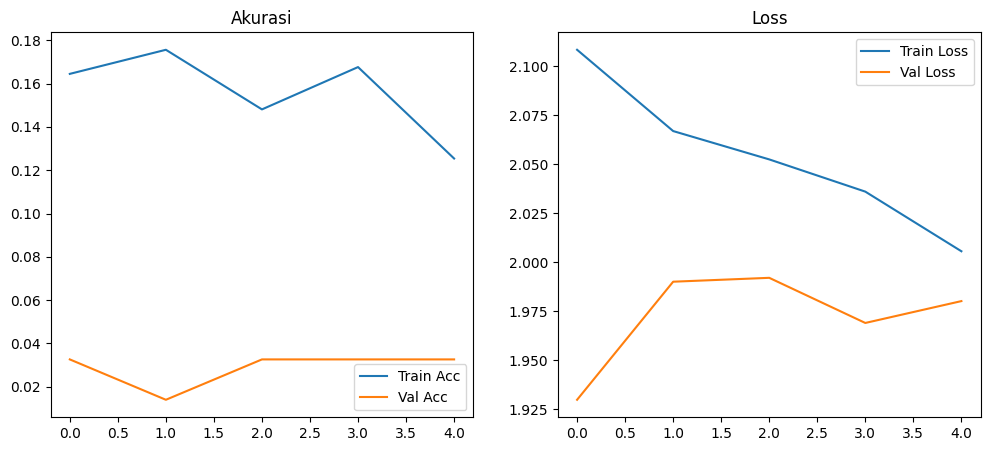

In [15]:
# --- STEP 2: MODEL ---

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model (biar gak overfitting)
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()


# --- STEP 3: FINAL TRAINING ---

# 1. Hitung Bobot Kelas untuk data imbalanced
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.unique(train_df["label"]), y=train_df["label"])
class_weights_dict = dict(enumerate(weights))

# 2. Re-Compile Model dengan LR 1e-4
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 3. Callbacks (EarlyStopping & ReduceLR)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

# 4. Eksekusi Training
print("🚀 Memulai Training Utama...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

# --- STEP 4: VISUALISASI ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [17]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss')
]

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 124s 563ms/step - accuracy: 0.1701 - loss: 2.0936 - val_accuracy: 0.0133 - val_loss: 2.0097 - learning_rate: 1.0000e-05
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 120s 545ms/step - accuracy: 0.1673 - loss: 2.0866 - val_accuracy: 0.0166 - val_loss: 2.0189 - learning_rate: 1.0000e-05
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 120s 546ms/step - accuracy: 0.1729 - loss: 1.9450 - val_accuracy: 0.0140 - val_loss: 2.0172 - learning_rate: 1.0000e-05
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 118s 538ms/step - accuracy: 0.1654 - loss: 2.1166 - val_accuracy: 0.0133 - val_loss: 2.0217 - learning_rate: 1.0000e-05
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 121s 549ms/step - accuracy: 0.1728 - loss: 1.9777 - val_accuracy: 0.0146 - val_loss: 2.0305 - learning_rate: 5.0000e-06
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 117s 530ms/step - accuracy: 0.1733 - loss: 1.8816 - val_accuracy: 0.0146 - val_loss: 2.0273 - learning_rate: 5.0000e-06


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Classification Report ---
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.00      0.00      0.00       165
          df       0.00      0.00      0.00        17
         mel       0.00      0.00      0.00       167
          nv       0.00      0.00      0.00      1006
        vasc       0.01      0.91      0.03        22

    accuracy                           0.01      1503
   macro avg       0.00      0.13      0.00      1503
weighted avg       0.00      0.01      0.00      1503


Model tersimpan sebagai skin_cancer_model.h5


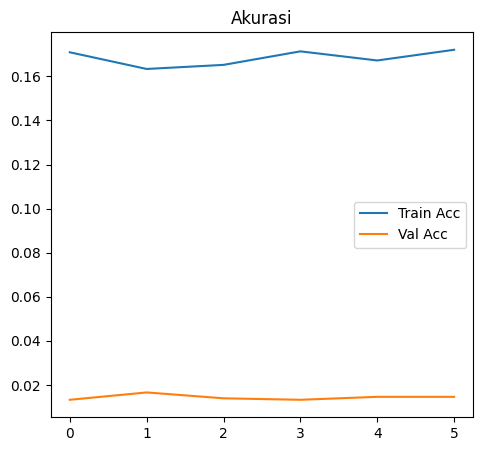

In [20]:
# Plot Hasil
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Akurasi")

# Prediksi & Report
y_true = test_generator.classes
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Simpan Model
model.save("skin_cancer_model.h5")
print("\nModel tersimpan sebagai skin_cancer_model.h5")